In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(0)
np.random.seed(0)

Using device: mps


In [3]:
dataset_path = "veg_subset"
print("Classes found:", sorted(os.listdir(dataset_path)))

Classes found: ['Bean', 'Garlic', 'Green Chili', 'Onion', 'Potato', 'Radish']


In [4]:
IMG_SIZE = 128
BATCH_SIZE = 32

basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

full_ds = datasets.ImageFolder(dataset_path, transform=basic_transform)
class_names = full_ds.classes
print("Classes:", class_names)
print("Total images:", len(full_ds))

n_train = int(0.8 * len(full_ds))
n_val = len(full_ds) - n_train
train_idx, val_idx = random_split(range(len(full_ds)), [n_train, n_val],
                                   generator=torch.Generator().manual_seed(0))

train_ds = Subset(full_ds, train_idx.indices)
val_ds = Subset(full_ds, val_idx.indices)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Train images:", len(train_ds))
print("Val images  :", len(val_ds))

Classes: ['Bean', 'Garlic', 'Green Chili', 'Onion', 'Potato', 'Radish']
Total images: 2332
Train images: 1865
Val images  : 467


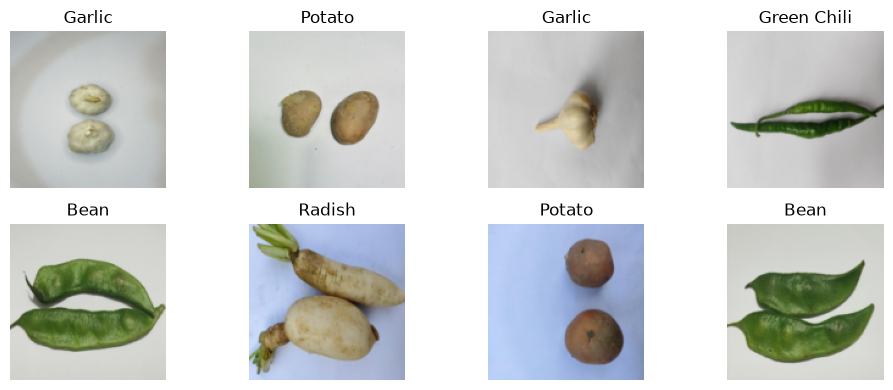

In [5]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [7]:
class Veg_CNN(nn.Module):
    def __init__(self, num_classes, p_dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(p_dropout)
        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = Veg_CNN(num_classes=len(class_names), p_dropout=0.0).to(device)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {n_params:,}")

Veg_CNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=6, bias=True)
)
Total trainable parameters: 2,121,638
